In [3]:
pip install torch transformers textblob nltk pandas -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import pandas as pd

# Download required NLTK data
try:
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

# 1. Load custom RoBERTa model from local path
model_path = "./my_fast_roberta_model"
print("Đang tải mô hình RoBERTa tùy chỉnh...")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
labels_roberta = ['Irrelevant', 'Negative', 'Neutral', 'Positive']
print("✓ Tải mô hình RoBERTa thành công!\n")

# 2. Load pre-trained DistilBERT for sentiment analysis
print("Đang tải mô hình DistilBERT...")
distilbert_pipeline = pipeline("sentiment-analysis", 
                               model="distilbert-base-uncased-finetuned-sst-2-english")
print("✓ Tải mô hình DistilBERT thành công!\n")

# 3. Initialize VADER Sentiment Analyzer
vader = SentimentIntensityAnalyzer()
print("✓ Khởi tạo VADER thành công!\n")

# ===== Phương pháp 1: Custom RoBERTa =====
def predict_sentiment_roberta(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        predicted_class_id = torch.argmax(logits, dim=-1).item()
    return labels_roberta[predicted_class_id]

# ===== Phương pháp 2: DistilBERT =====
def predict_sentiment_distilbert(text):
    result = distilbert_pipeline(text[:512])[0]
    return f"{result['label']} ({result['score']:.2f})"

# ===== Phương pháp 3: VADER (Rule-based) =====
def predict_sentiment_vader(text):
    scores = vader.polarity_scores(text)
    compound = scores['compound']
    if compound >= 0.05:
        return f"POSITIVE ({scores['pos']:.2f})"
    elif compound <= -0.05:
        return f"NEGATIVE ({scores['neg']:.2f})"
    else:
        return f"NEUTRAL ({scores['neu']:.2f})"

# ===== Phương pháp 4: TextBlob (Lexicon-based) =====
def predict_sentiment_textblob(text):
    blob = TextBlob(text)
    polarity = blob.sentiment.polarity
    if polarity > 0.1:
        return f"POSITIVE ({polarity:.2f})"
    elif polarity < -0.1:
        return f"NEGATIVE ({polarity:.2f})"
    else:
        return f"NEUTRAL ({polarity:.2f})"

# ===== Hàm tổng hợp để so sánh tất cả các phương pháp =====
def analyze_sentiment_multi_methods(text):
    print(f"Câu: '{text}'")
    print("-" * 70)
    
    roberta_result = predict_sentiment_roberta(text)
    distilbert_result = predict_sentiment_distilbert(text)
    vader_result = predict_sentiment_vader(text)
    textblob_result = predict_sentiment_textblob(text)
    
    print(f"1. Custom RoBERTa:     {roberta_result}")
    print(f"2. DistilBERT:         {distilbert_result}")
    print(f"3. VADER (Rule-based): {vader_result}")
    print(f"4. TextBlob:           {textblob_result}")
    print()
    
    return {
        'Text': text,
        'RoBERTa': roberta_result,
        'DistilBERT': distilbert_result,
        'VADER': vader_result,
        'TextBlob': textblob_result
    }

# 4. Thử nghiệm với các câu mới
test_sentences = [
    "This new Borderlands update is absolutely amazing! I love it.",
    "My internet connection is so bad right now, I can't even play.",
    "You are an idiot",
    "I don't care about the new update, it's just another patch.",
    "You're dragging me!"
]

results = []
for sentence in test_sentences:
    result = analyze_sentiment_multi_methods(sentence)
    results.append(result)

# Tạo bảng kết quả để dễ so sánh
print("\n" + "=" * 100)
print("BẢNG SO SÁNH KẾT QUẢ TỪ TẤT CẢ CÁC PHƯƠNG PHÁP")
print("=" * 100)
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\nhatl\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Đang tải mô hình RoBERTa tùy chỉnh...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Tải mô hình RoBERTa thành công!

Đang tải mô hình DistilBERT...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ Tải mô hình DistilBERT thành công!

✓ Khởi tạo VADER thành công!

Câu: 'This new Borderlands update is absolutely amazing! I love it.'
----------------------------------------------------------------------
1. Custom RoBERTa:     Positive
2. DistilBERT:         POSITIVE (1.00)
3. VADER (Rule-based): POSITIVE (0.56)
4. TextBlob:           POSITIVE (0.46)

Câu: 'My internet connection is so bad right now, I can't even play.'
----------------------------------------------------------------------
1. Custom RoBERTa:     Negative
2. DistilBERT:         NEGATIVE (1.00)
3. VADER (Rule-based): NEGATIVE (0.42)
4. TextBlob:           NEGATIVE (-0.21)

Câu: 'You are an idiot'
----------------------------------------------------------------------
1. Custom RoBERTa:     Negative
2. DistilBERT:         NEGATIVE (1.00)
3. VADER (Rule-based): NEGATIVE (0.52)
4. TextBlob:           NEGATIVE (-0.80)

Câu: 'I don't care about the new update, it's just another patch.'
-------------------------------------

In [5]:
# ===== CELL 3A: IMPORT + CHUẨN BỊ DỮ LIỆU TEST =====
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Tập dữ liệu kiểm tra (Test Dataset)
test_data = [
    ("This new Borderlands update is absolutely amazing! I love it.", 3),  # Positive
    ("My internet connection is so bad right now, I can't even play.", 1),  # Negative
    ("You are an idiot", 1),  # Negative
    ("I don't care about the new update, it's just another patch.", 2),  # Neutral
    ("Great game, highly recommended!", 3),  # Positive
]

label_names = ['Irrelevant', 'Negative', 'Neutral', 'Positive']
y_true = [item[1] for item in test_data]
test_texts = [item[0] for item in test_data]

print("🔍 DỮ LIỆU KIỂM TRA")
print("=" * 80)
print(f"Số mẫu kiểm tra: {len(test_data)}")
print()

🔍 DỮ LIỆU KIỂM TRA
Số mẫu kiểm tra: 5



In [6]:
# ===== CELL 3B: LẤY DỰ ĐOÁN TỪ CÁC MÔ HÌNH =====

# Hàm dự đoán cho từng mô hình
def get_roberta_predictions(texts):
    predictions = []
    for text in texts:
        pred = predict_sentiment_roberta(text)
        predictions.append(label_names.index(pred))
    return np.array(predictions)

def get_distilbert_predictions(texts):
    predictions = []
    for text in texts:
        result = distilbert_pipeline(text[:512])[0]
        label = result['label'].upper()
        predictions.append(3 if label == 'POSITIVE' else 1)
    return np.array(predictions)

def get_vader_predictions(texts):
    predictions = []
    for text in texts:
        scores = vader.polarity_scores(text)
        compound = scores['compound']
        if compound >= 0.05:
            predictions.append(3)
        elif compound <= -0.05:
            predictions.append(1)
        else:
            predictions.append(2)
    return np.array(predictions)

def get_textblob_predictions(texts):
    predictions = []
    for text in texts:
        blob = TextBlob(text)
        polarity = blob.sentiment.polarity
        if polarity > 0.1:
            predictions.append(3)
        elif polarity < -0.1:
            predictions.append(1)
        else:
            predictions.append(2)
    return np.array(predictions)

# Lấy dự đoán từ tất cả mô hình
print("⏳ Đang lấy dự đoán từ 4 mô hình...")
print("-" * 80)

y_pred_roberta = get_roberta_predictions(test_texts)
print("✓ RoBERTa")

y_pred_distilbert = get_distilbert_predictions(test_texts)
print("✓ DistilBERT")

y_pred_vader = get_vader_predictions(test_texts)
print("✓ VADER")

y_pred_textblob = get_textblob_predictions(test_texts)
print("✓ TextBlob")

print()

⏳ Đang lấy dự đoán từ 4 mô hình...
--------------------------------------------------------------------------------
✓ RoBERTa
✓ DistilBERT
✓ VADER
✓ TextBlob



In [7]:
# ===== CELL 3C: TÍNH TOÁN METRICS VÀ HIỂN THỊ BẢNG TÓM TẮT =====

def calculate_metrics(y_true, y_pred, model_name):
    """Tính toán các chỉ số đánh giá"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    conf_matrix = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
    
    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'conf_matrix': conf_matrix,
        'y_pred': y_pred
    }

# Tính toán metrics cho 4 mô hình
print("📊 TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ")
print("=" * 80)

metrics_roberta = calculate_metrics(y_true, y_pred_roberta, 'RoBERTa')
metrics_distilbert = calculate_metrics(y_true, y_pred_distilbert, 'DistilBERT')
metrics_vader = calculate_metrics(y_true, y_pred_vader, 'VADER')
metrics_textblob = calculate_metrics(y_true, y_pred_textblob, 'TextBlob')

all_metrics = [metrics_roberta, metrics_distilbert, metrics_vader, metrics_textblob]

# Hiển thị bảng tóm tắt
print("\n🎯 BẢNG TÓM TẮT CÁC CHỈ SỐ")
print("=" * 80)

summary_data = []
for metrics in all_metrics:
    summary_data.append({
        'Mô hình': metrics['model_name'],
        'Accuracy': f"{metrics['accuracy']:.4f}",
        'Precision': f"{metrics['precision']:.4f}",
        'Recall': f"{metrics['recall']:.4f}",
        'F1-Score': f"{metrics['f1']:.4f}"
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

📊 TÍNH TOÁN CÁC CHỈ SỐ ĐÁNH GIÁ

🎯 BẢNG TÓM TẮT CÁC CHỈ SỐ
   Mô hình Accuracy Precision Recall F1-Score
   RoBERTa   0.6000    0.6667 0.6000   0.5867
DistilBERT   0.8000    0.6667 0.8000   0.7200
     VADER   0.8000    0.6667 0.8000   0.7200
  TextBlob   0.8000    0.6667 0.8000   0.7200



🔢 MA TRẬN NHẦM LẪN (CONFUSION MATRIX)


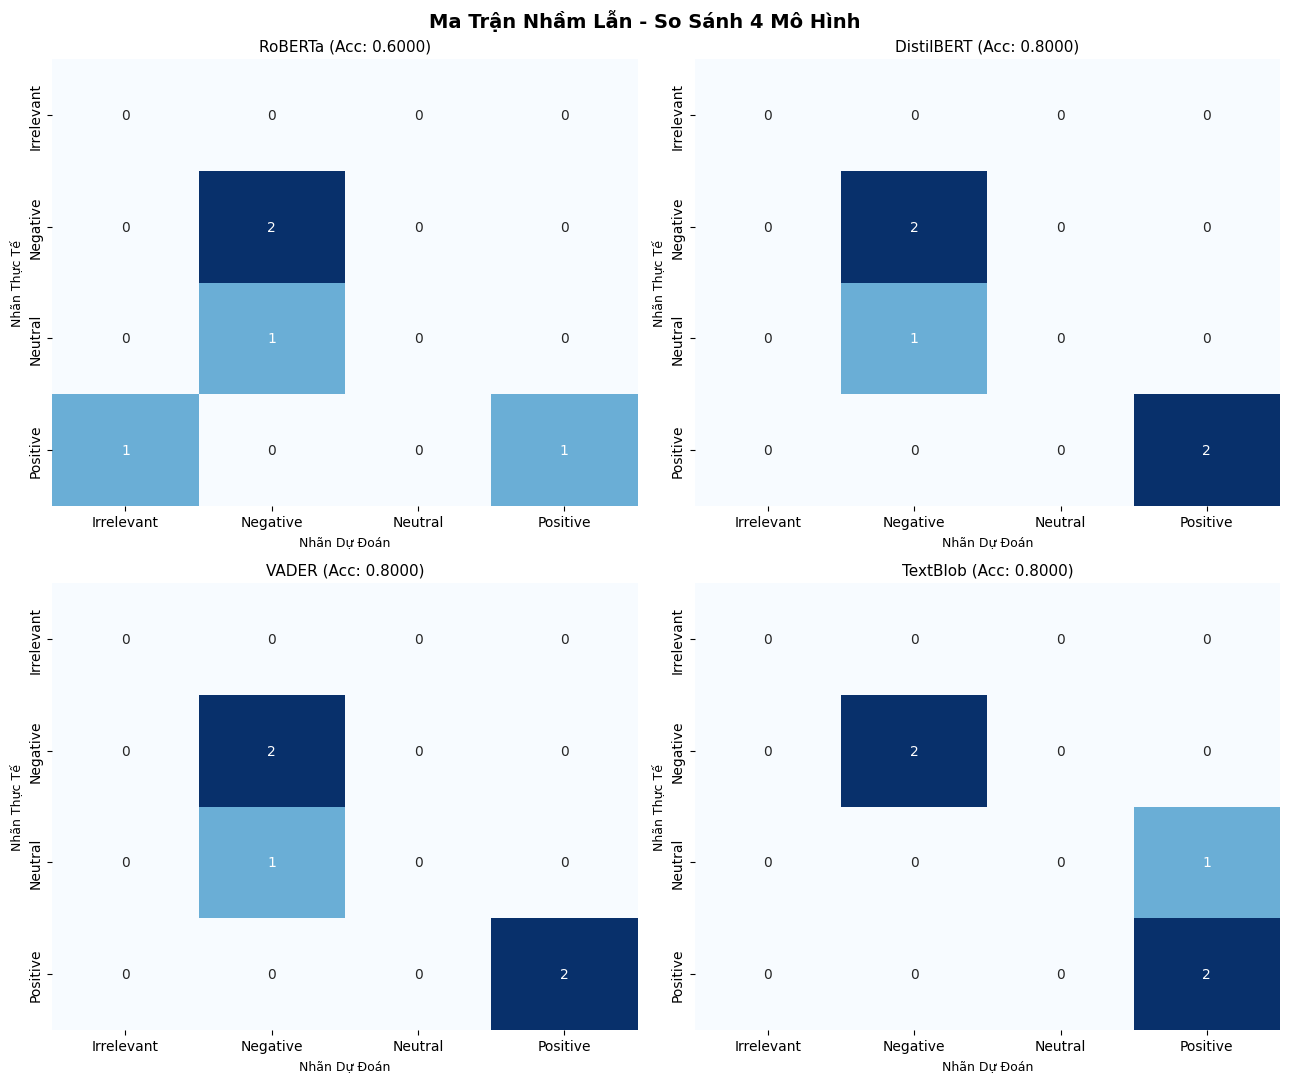

In [8]:
# ===== CELL 3D: MA TRẬN NHẦM LẪN (CONFUSION MATRIX) =====

print("\n🔢 MA TRẬN NHẦM LẪN (CONFUSION MATRIX)")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
fig.suptitle('Ma Trận Nhầm Lẫn - So Sánh 4 Mô Hình', fontsize=14, fontweight='bold')

models_and_metrics = [
    (metrics_roberta, axes[0, 0]),
    (metrics_distilbert, axes[0, 1]),
    (metrics_vader, axes[1, 0]),
    (metrics_textblob, axes[1, 1])
]

for metrics, ax in models_and_metrics:
    cm = metrics['conf_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                xticklabels=label_names, yticklabels=label_names, cbar=False)
    ax.set_title(f"{metrics['model_name']} (Acc: {metrics['accuracy']:.4f})", fontsize=11)
    ax.set_ylabel('Nhãn Thực Tế', fontsize=9)
    ax.set_xlabel('Nhãn Dự Đoán', fontsize=9)

plt.tight_layout()
plt.show()


📊 BIỂU ĐỒ SO SÁNH CÁC MÔ HÌNH


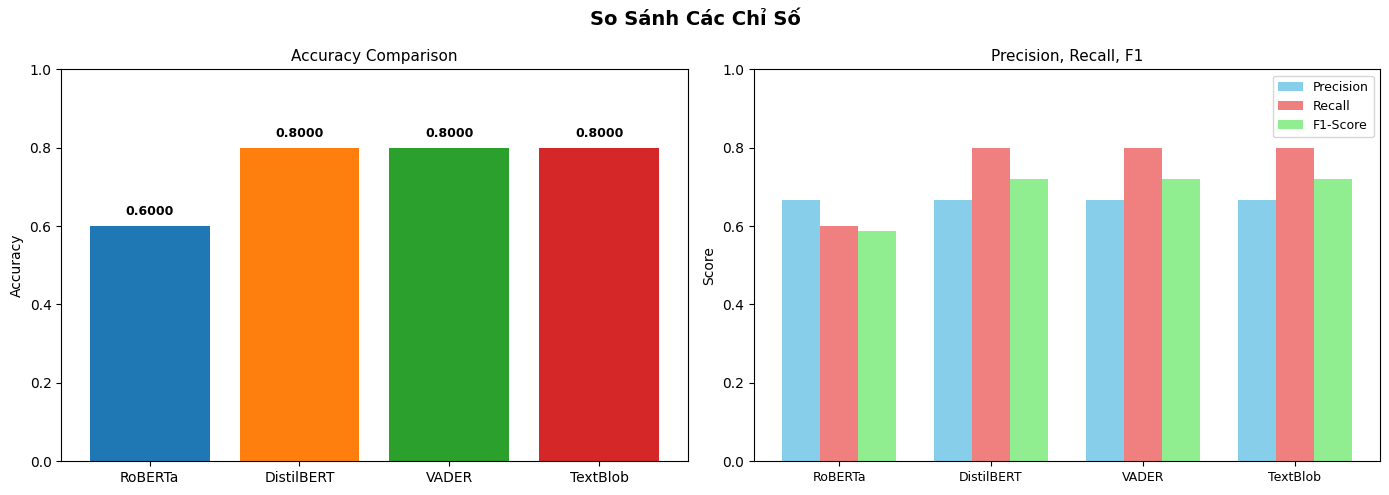

In [9]:
# ===== CELL 3E: BIỂU ĐỒ SO SÁNH CÁC METRICS =====

print("\n📊 BIỂU ĐỒ SO SÁNH CÁC MÔ HÌNH")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('So Sánh Các Chỉ Số', fontsize=14, fontweight='bold')

# Biểu đồ 1: Accuracy
ax1 = axes[0]
models = [m['model_name'] for m in all_metrics]
accuracies = [m['accuracy'] for m in all_metrics]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars = ax1.bar(models, accuracies, color=colors)
ax1.set_ylabel('Accuracy', fontsize=10)
ax1.set_title('Accuracy Comparison', fontsize=11)
ax1.set_ylim([0, 1])
for i, v in enumerate(accuracies):
    ax1.text(i, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# Biểu đồ 2: Precision, Recall, F1
ax2 = axes[1]
x = np.arange(len(models))
width = 0.25
precisions = [m['precision'] for m in all_metrics]
recalls = [m['recall'] for m in all_metrics]
f1s = [m['f1'] for m in all_metrics]
ax2.bar(x - width, precisions, width, label='Precision', color='skyblue')
ax2.bar(x, recalls, width, label='Recall', color='lightcoral')
ax2.bar(x + width, f1s, width, label='F1-Score', color='lightgreen')
ax2.set_ylabel('Score', fontsize=10)
ax2.set_title('Precision, Recall, F1', fontsize=11)
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=9)
ax2.legend(fontsize=9)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

In [10]:
# ===== CELL 3F: CLASSIFICATION REPORT CHI TIẾT =====

print("\n📄 CHI TIẾT CLASSIFICATION REPORT")
print("=" * 80)

# Lấy danh sách các lớp thực sự có trong y_true
labels = sorted(list(set(y_true)))
target_names_filtered = [label_names[i] for i in labels]

for metrics in all_metrics:
    print(f"\n{'🔹 ' + metrics['model_name'].upper()}")
    print("-" * 80)
    print(classification_report(y_true, metrics['y_pred'], 
                                target_names=target_names_filtered, 
                                labels=labels,
                                digits=4, zero_division=0))

print("\n✅ ĐÁNH GIÁ MÔ HÌNH HOÀN TẤT!")


📄 CHI TIẾT CLASSIFICATION REPORT

🔹 ROBERTA
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.6667    1.0000    0.8000         2
     Neutral     0.0000    0.0000    0.0000         1
    Positive     1.0000    0.5000    0.6667         2

   micro avg     0.7500    0.6000    0.6667         5
   macro avg     0.5556    0.5000    0.4889         5
weighted avg     0.6667    0.6000    0.5867         5


🔹 DISTILBERT
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

    Negative     0.6667    1.0000    0.8000         2
     Neutral     0.0000    0.0000    0.0000         1
    Positive     1.0000    1.0000    1.0000         2

    accuracy                         0.8000         5
   macro avg     0.5556    0.6667    0.6000         5
weighted avg     0.6667    0.8000    0.7200         5


🔹 VADER
--------